In [7]:
# Install 
!pip install ultralytics -q
!pip install grad-cam -q

import os
import torch
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
from IPython.display import Image as IPImage, display
from ultralytics import YOLO


# Model path 
MODEL_PATH = "/kaggle/input/datasets/fatemadev/cxr-yolov8s-trained-model/runs/full_yolov8s_1024/weights/best.pt"

DATASET_ROOT = None
candidates = []

# Direct known paths
known_paths = [
    "/kaggle/input/datasets/fatemadev/cxr-yolo-8class-dataset/dataset",
    "/kaggle/input/datasets/fatemadev/cxr-yolo-8class-dataset",
    "/kaggle/input/cxr-yolo-8class-dataset/dataset",
]

for p in known_paths:
    if Path(p).exists():
        print(f" Exists: {p}")
        candidates.append(p)

#  Deep rglob for "images/test"
print("\n=== Deep search for images/test ===\n")
for test_dir in Path("/kaggle/input").rglob("images/test"):
    if test_dir.is_dir():
        n = len(list(test_dir.glob("*.png")))
        if n > 100:
            dataset_path = str(test_dir.parent.parent)
            print(f" Found dataset: {dataset_path}")
            print(f"   Test images: {n}")
            candidates.append(dataset_path)

# Pick first valid
if candidates:
    DATASET_ROOT = candidates[0]
    print(f"\n DATASET_ROOT = {DATASET_ROOT}")
else:
    print("\n Dataset nahi mila")
    print("\n=== /kaggle/input ke andar ===")
    for item in Path("/kaggle/input").iterdir():
        print(f" {item.name}/")
        if item.is_dir():
            for sub in list(item.iterdir())[:10]:
                print(f"   ├─ {sub.name}")

# Final verify
print(f"\n=== FINAL CHECK ===")
print(f"Model exists: {Path(MODEL_PATH).exists()}")
print(f"Dataset root: {DATASET_ROOT}")
if DATASET_ROOT:
    for split in ["train", "val", "test"]:
        n = len(list((Path(DATASET_ROOT) / f"images/{split}").glob("*.png")))
        print(f"  {split}: {n} images")

 Exists: /kaggle/input/datasets/fatemadev/cxr-yolo-8class-dataset/dataset
 Exists: /kaggle/input/datasets/fatemadev/cxr-yolo-8class-dataset

=== Deep search for images/test ===

 Found dataset: /kaggle/input/datasets/fatemadev/cxr-yolo-8class-dataset/dataset
   Test images: 657

 DATASET_ROOT = /kaggle/input/datasets/fatemadev/cxr-yolo-8class-dataset/dataset

=== FINAL CHECK ===
Model exists: True
Dataset root: /kaggle/input/datasets/fatemadev/cxr-yolo-8class-dataset/dataset
  train: 3066 images
  val: 657 images
  test: 657 images


In [15]:
# Evaluation 
eval_yaml = {
    'path': '/kaggle/working',                         
    'train': f'{DATASET_ROOT}/images/train',            
    'val': f'{DATASET_ROOT}/images/val',
    'test': f'{DATASET_ROOT}/images/test',
    'nc': 8,
    'names': [
        'Aortic enlargement',
        'Cardiomegaly',
        'Pleural thickening',
        'Pulmonary fibrosis',
        'Lung Opacity',
        'Other lesion',
        'Pleural effusion',
        'Nodule/Mass',
    ]
}

with open('/kaggle/working/dataset_eval.yaml', 'w') as f:
    yaml.dump(eval_yaml, f, default_flow_style=False, sort_keys=False)

print(" dataset_eval.yaml created:")
print(open('/kaggle/working/dataset_eval.yaml').read())

 dataset_eval.yaml created:
path: /kaggle/working
train: /kaggle/input/datasets/fatemadev/cxr-yolo-8class-dataset/dataset/images/train
val: /kaggle/input/datasets/fatemadev/cxr-yolo-8class-dataset/dataset/images/val
test: /kaggle/input/datasets/fatemadev/cxr-yolo-8class-dataset/dataset/images/test
nc: 8
names:
- Aortic enlargement
- Cardiomegaly
- Pleural thickening
- Pulmonary fibrosis
- Lung Opacity
- Other lesion
- Pleural effusion
- Nodule/Mass



In [16]:
from ultralytics import YOLO

# Load best model
model = YOLO(MODEL_PATH)
print(f"Model classes: {model.names}\n")

# Test set par evaluate. mAP@0.4 (original VinDr-CXR metric)
print("=== Evaluating on test set with mAP@0.4 ===")
metrics = model.val(
    data='/kaggle/working/dataset_eval.yaml',
    split='test',
    iou=0.4,              # Original challenge metric
    conf=0.25,
    save_json=True,
    plots=True,
    project='/kaggle/working/evaluation',
    name='test_mAP04',
    exist_ok=True,
)

print(f"OVERALL mAP@0.4: {metrics.box.map:.4f}")
print(f"Overall mAP@0.5: {metrics.box.map50:.4f}")


Model classes: {0: 'Aortic enlargement', 1: 'Cardiomegaly', 2: 'Pleural thickening', 3: 'Pulmonary fibrosis', 4: 'Lung Opacity', 5: 'Other lesion', 6: 'Pleural effusion', 7: 'Nodule/Mass'}

=== Evaluating on test set with mAP@0.4 ===
Ultralytics 8.4.164 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 11,128,680 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.7±1.4 ms, read: 73.7±8.9 MB/s, size: 3410.9 KB)
val: Scanning /kaggle/input/datasets/fatemadev/cxr-yolo-8class-dataset/dataset/labels/test... 657 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 657/657 33.6it/s 19.6s0.1ss
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/fatemadev/cxr-yolo-8class-dataset/dataset/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 42/42 1.2it/s 35.9s0.6ss
                   all        657       2908      0.633      0.364   

=== Confusion Matrix ===


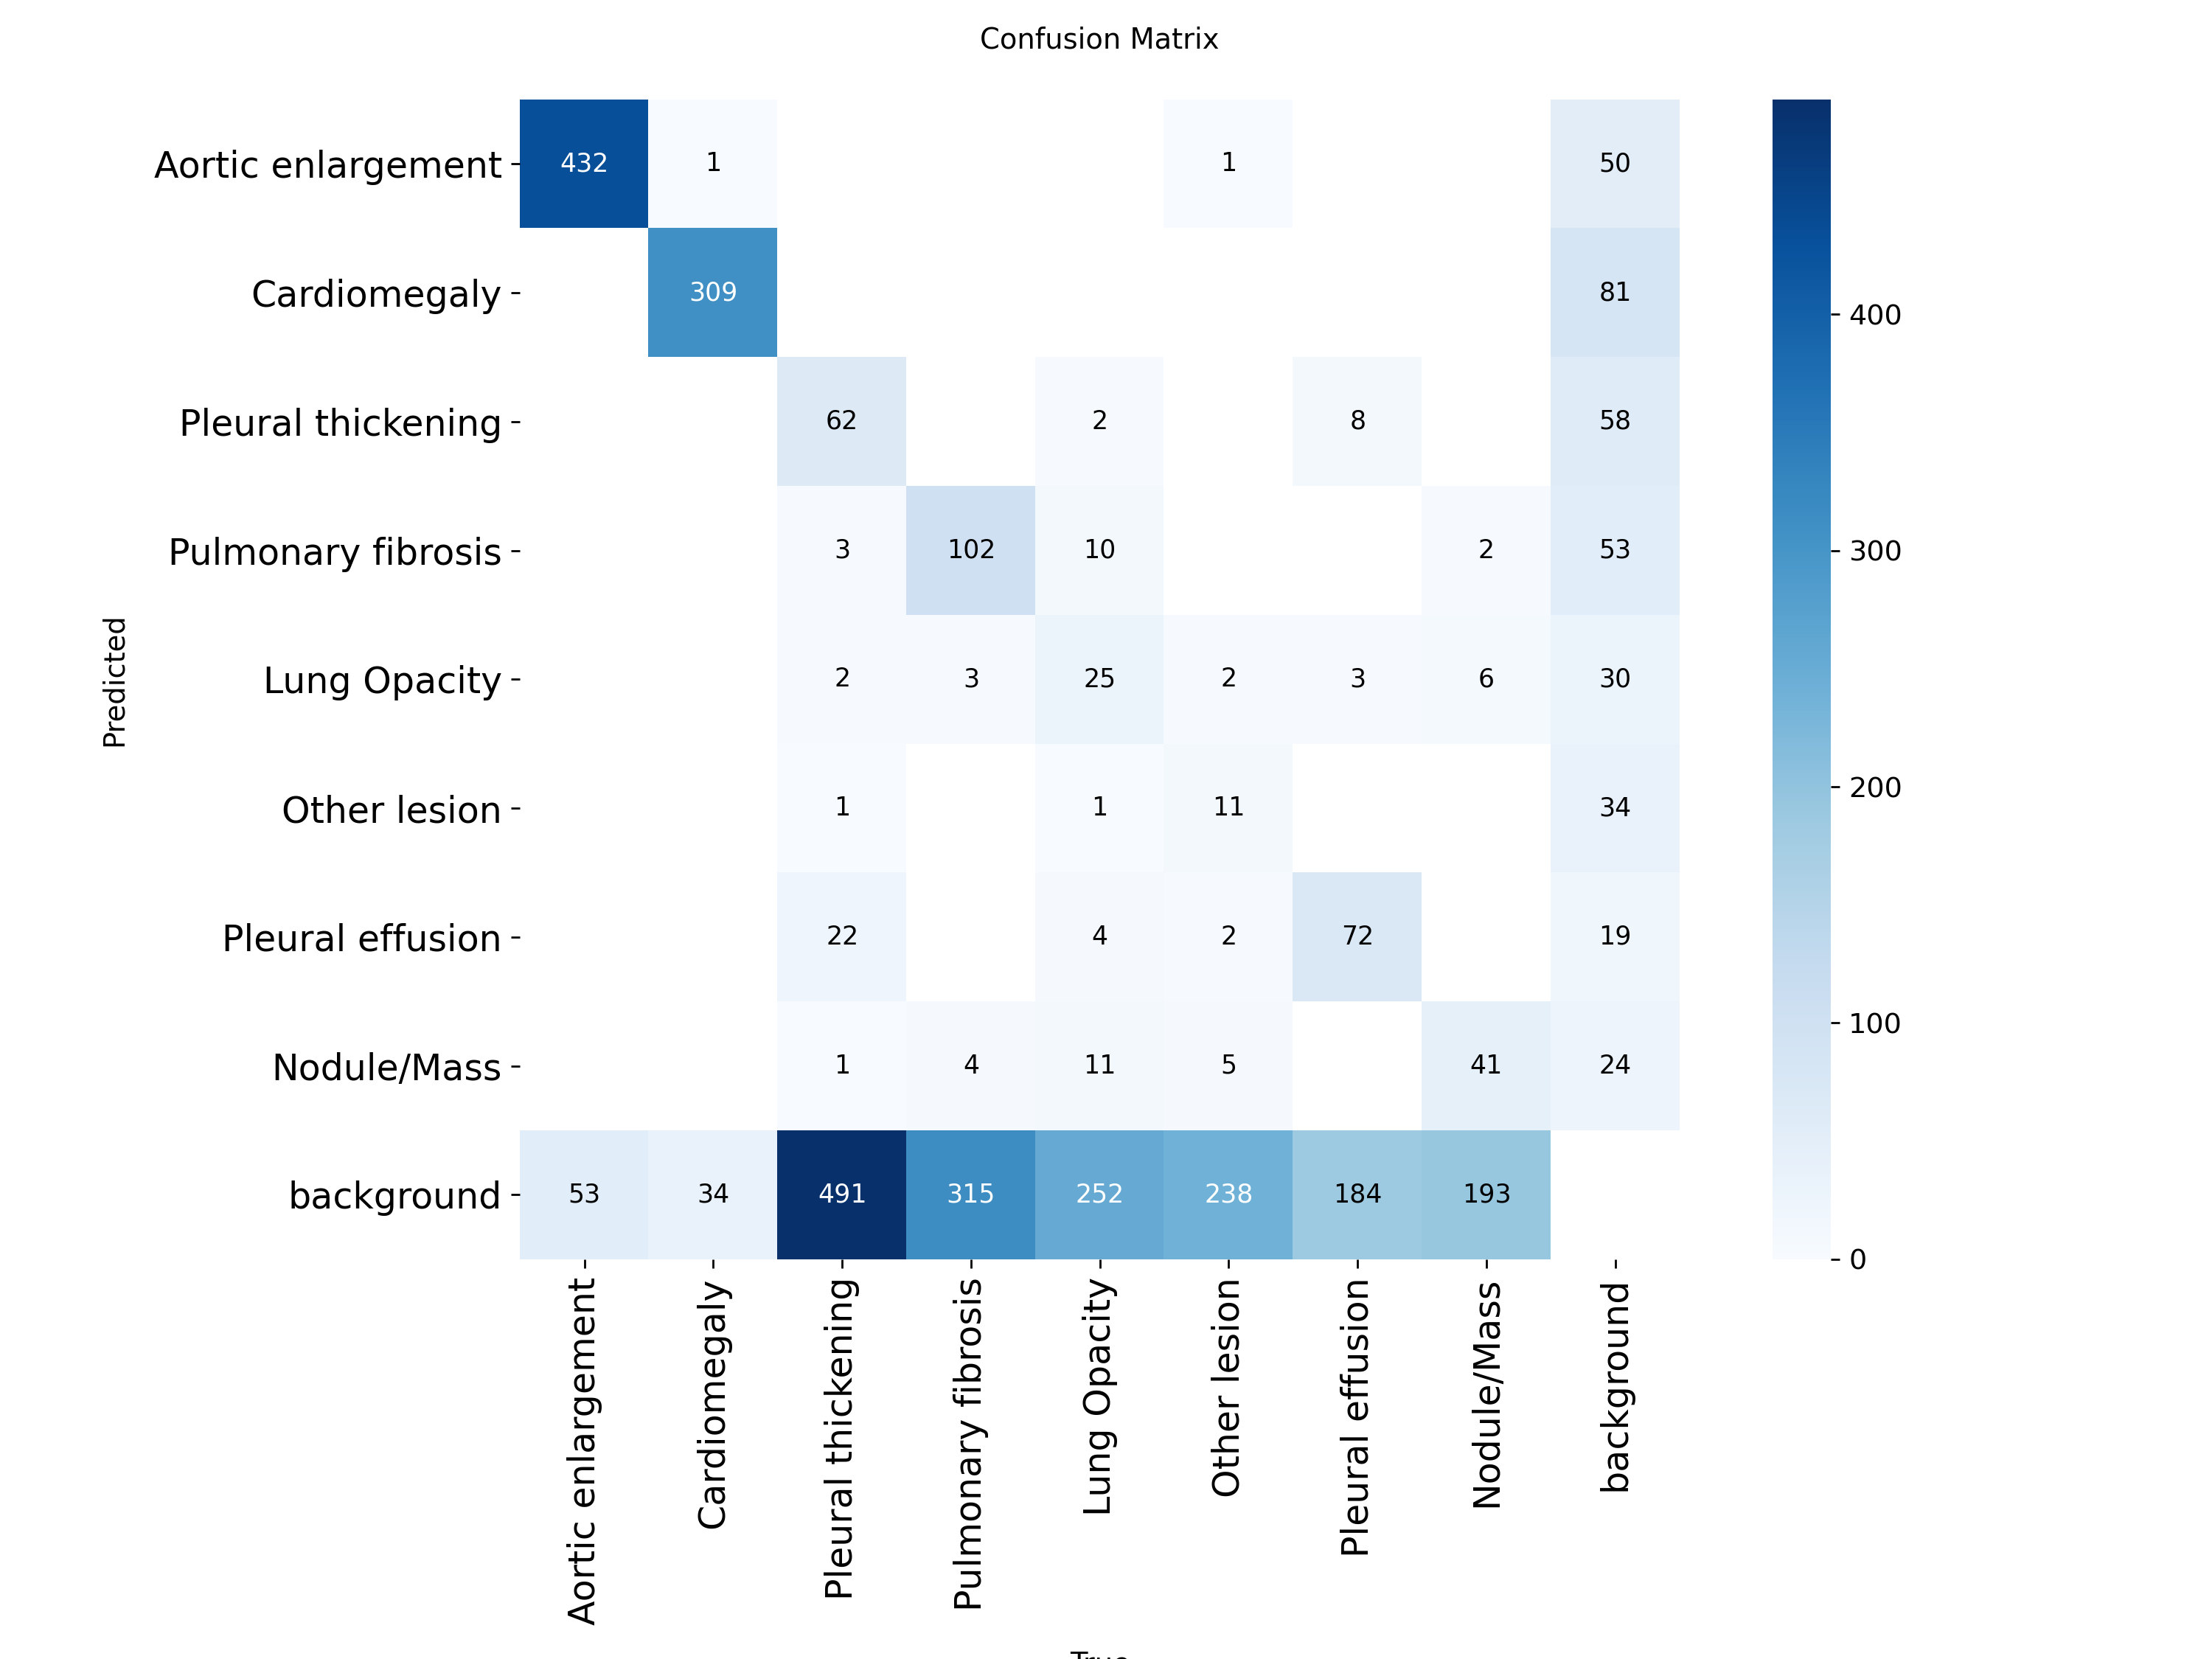


=== Normalized Confusion Matrix ===


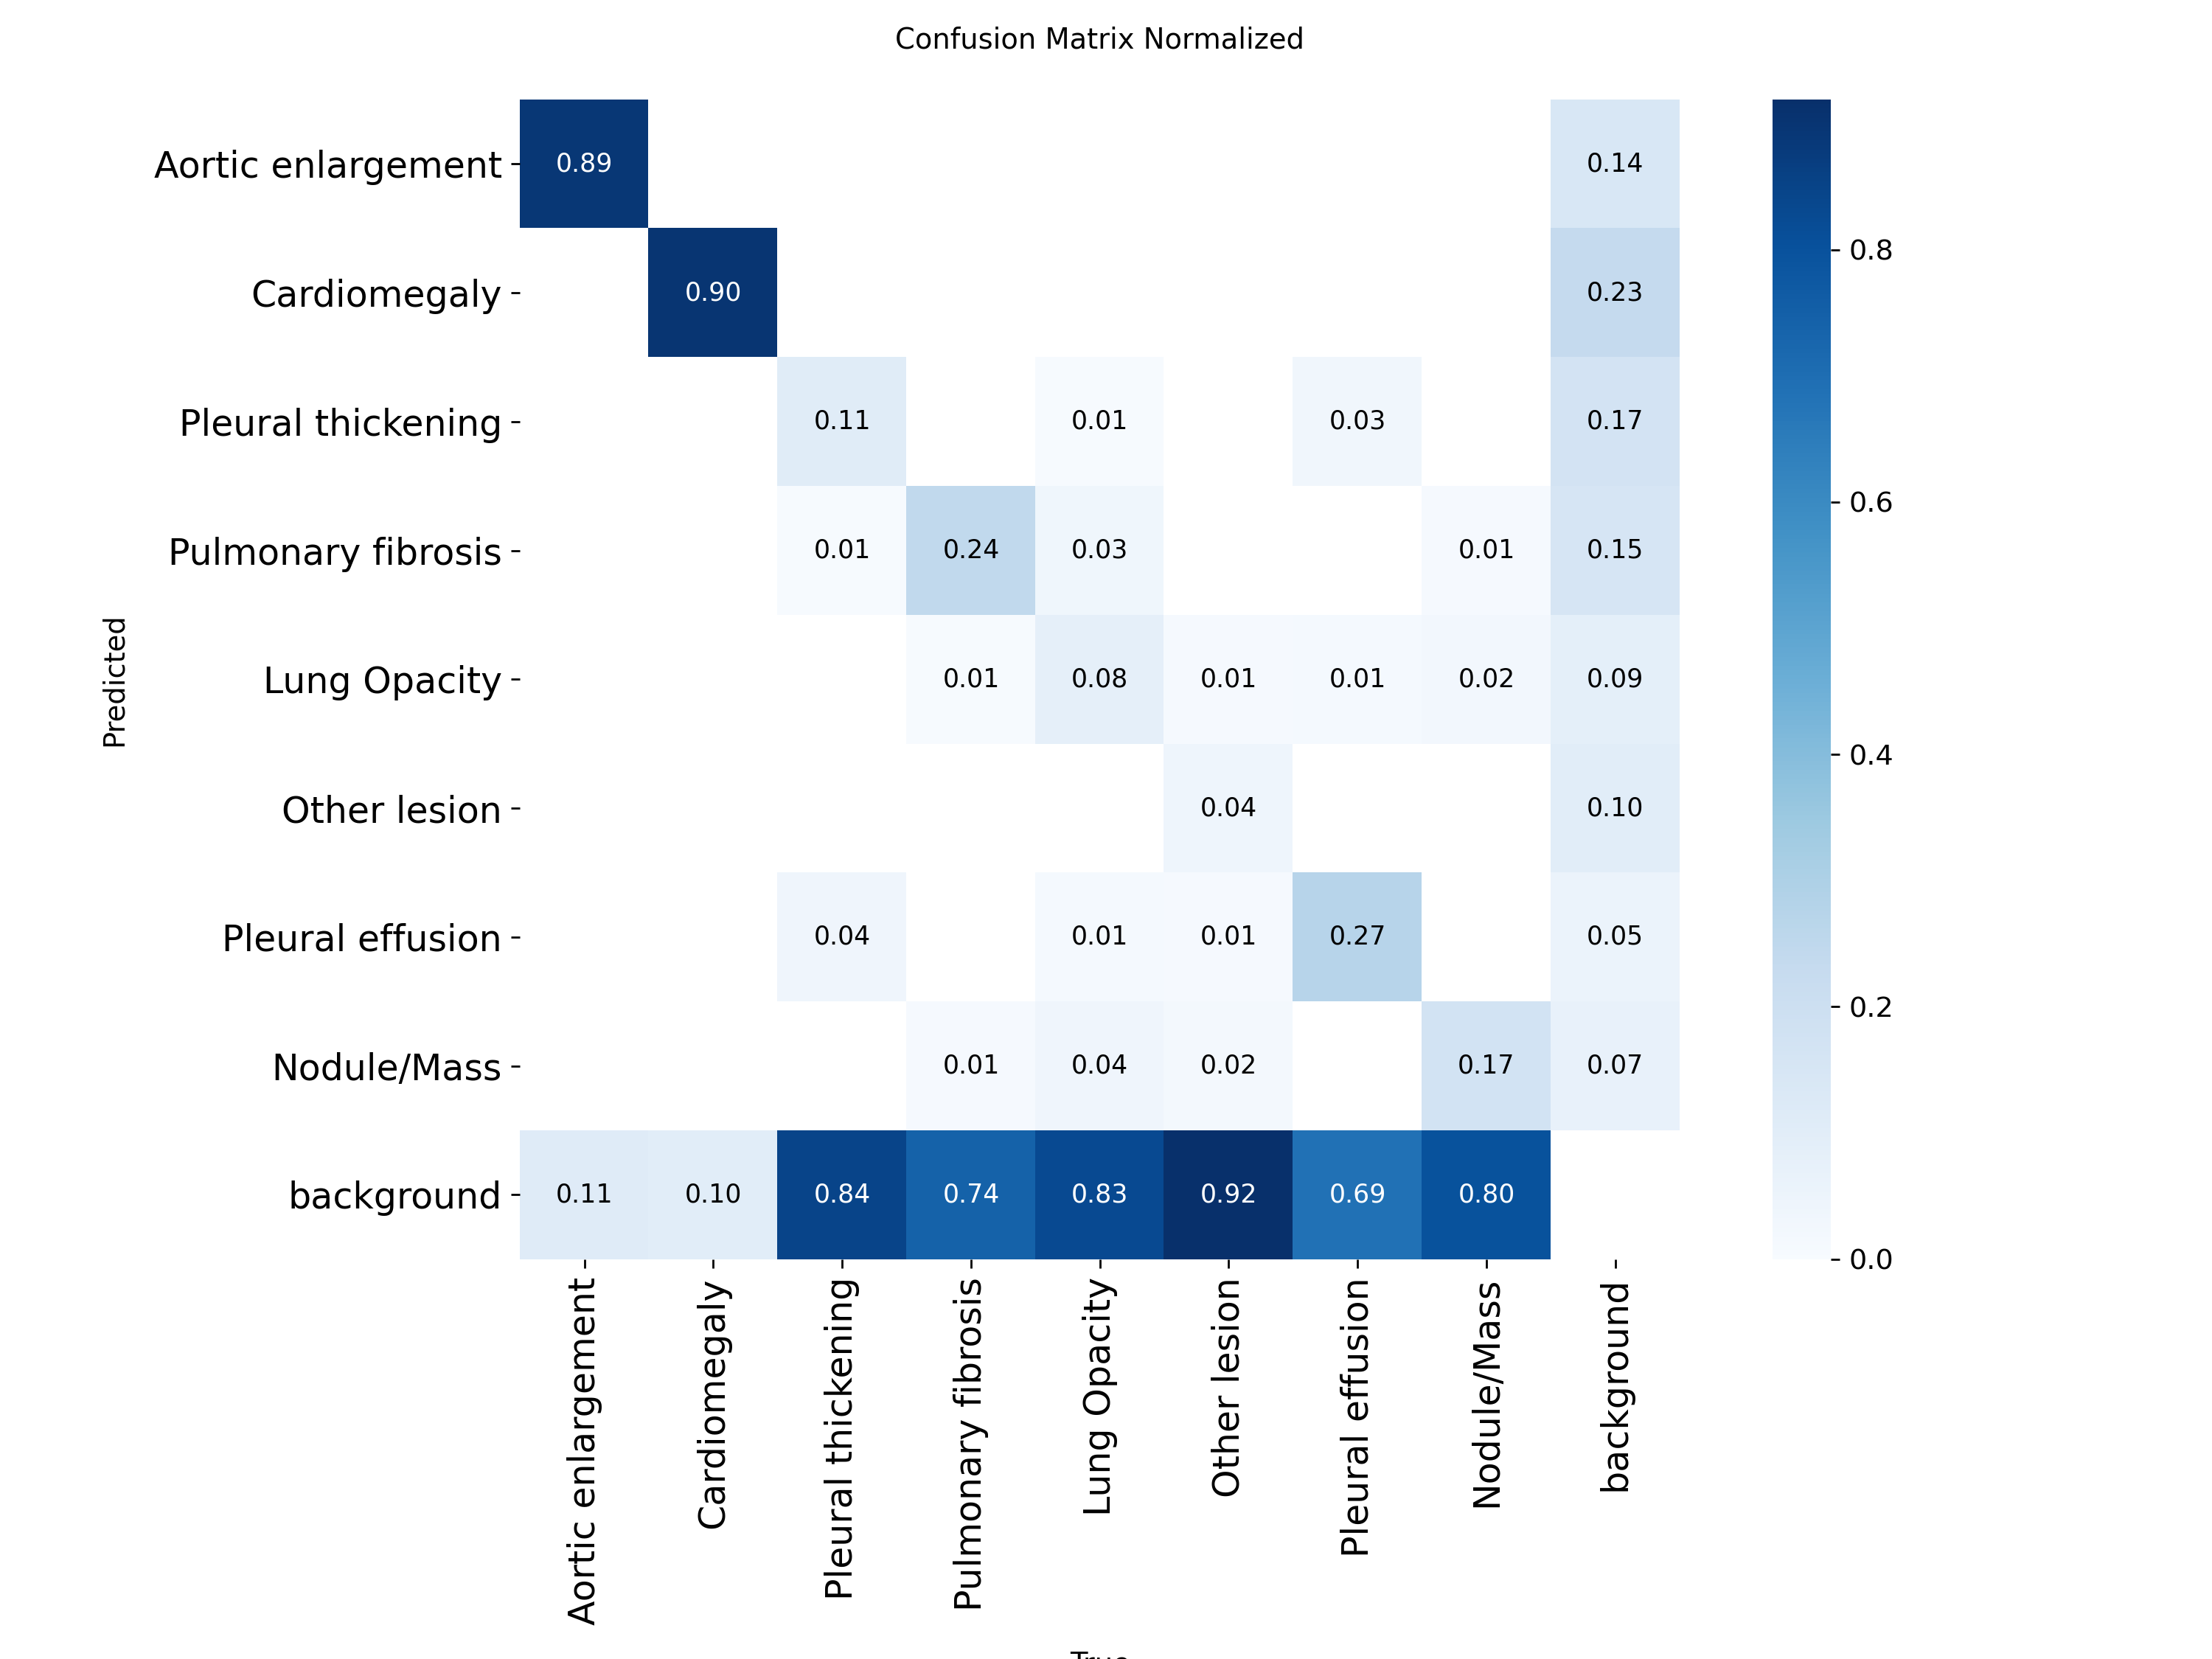


=== PR Curve ===


FileNotFoundError: No such file or directory: '/kaggle/working/evaluation/test_mAP04/PR_curve.png'

FileNotFoundError: No such file or directory: '/kaggle/working/evaluation/test_mAP04/PR_curve.png'

<IPython.core.display.Image object>


=== F1 Curve ===


FileNotFoundError: No such file or directory: '/kaggle/working/evaluation/test_mAP04/F1_curve.png'

FileNotFoundError: No such file or directory: '/kaggle/working/evaluation/test_mAP04/F1_curve.png'

<IPython.core.display.Image object>


=== Val Batch Predictions ===


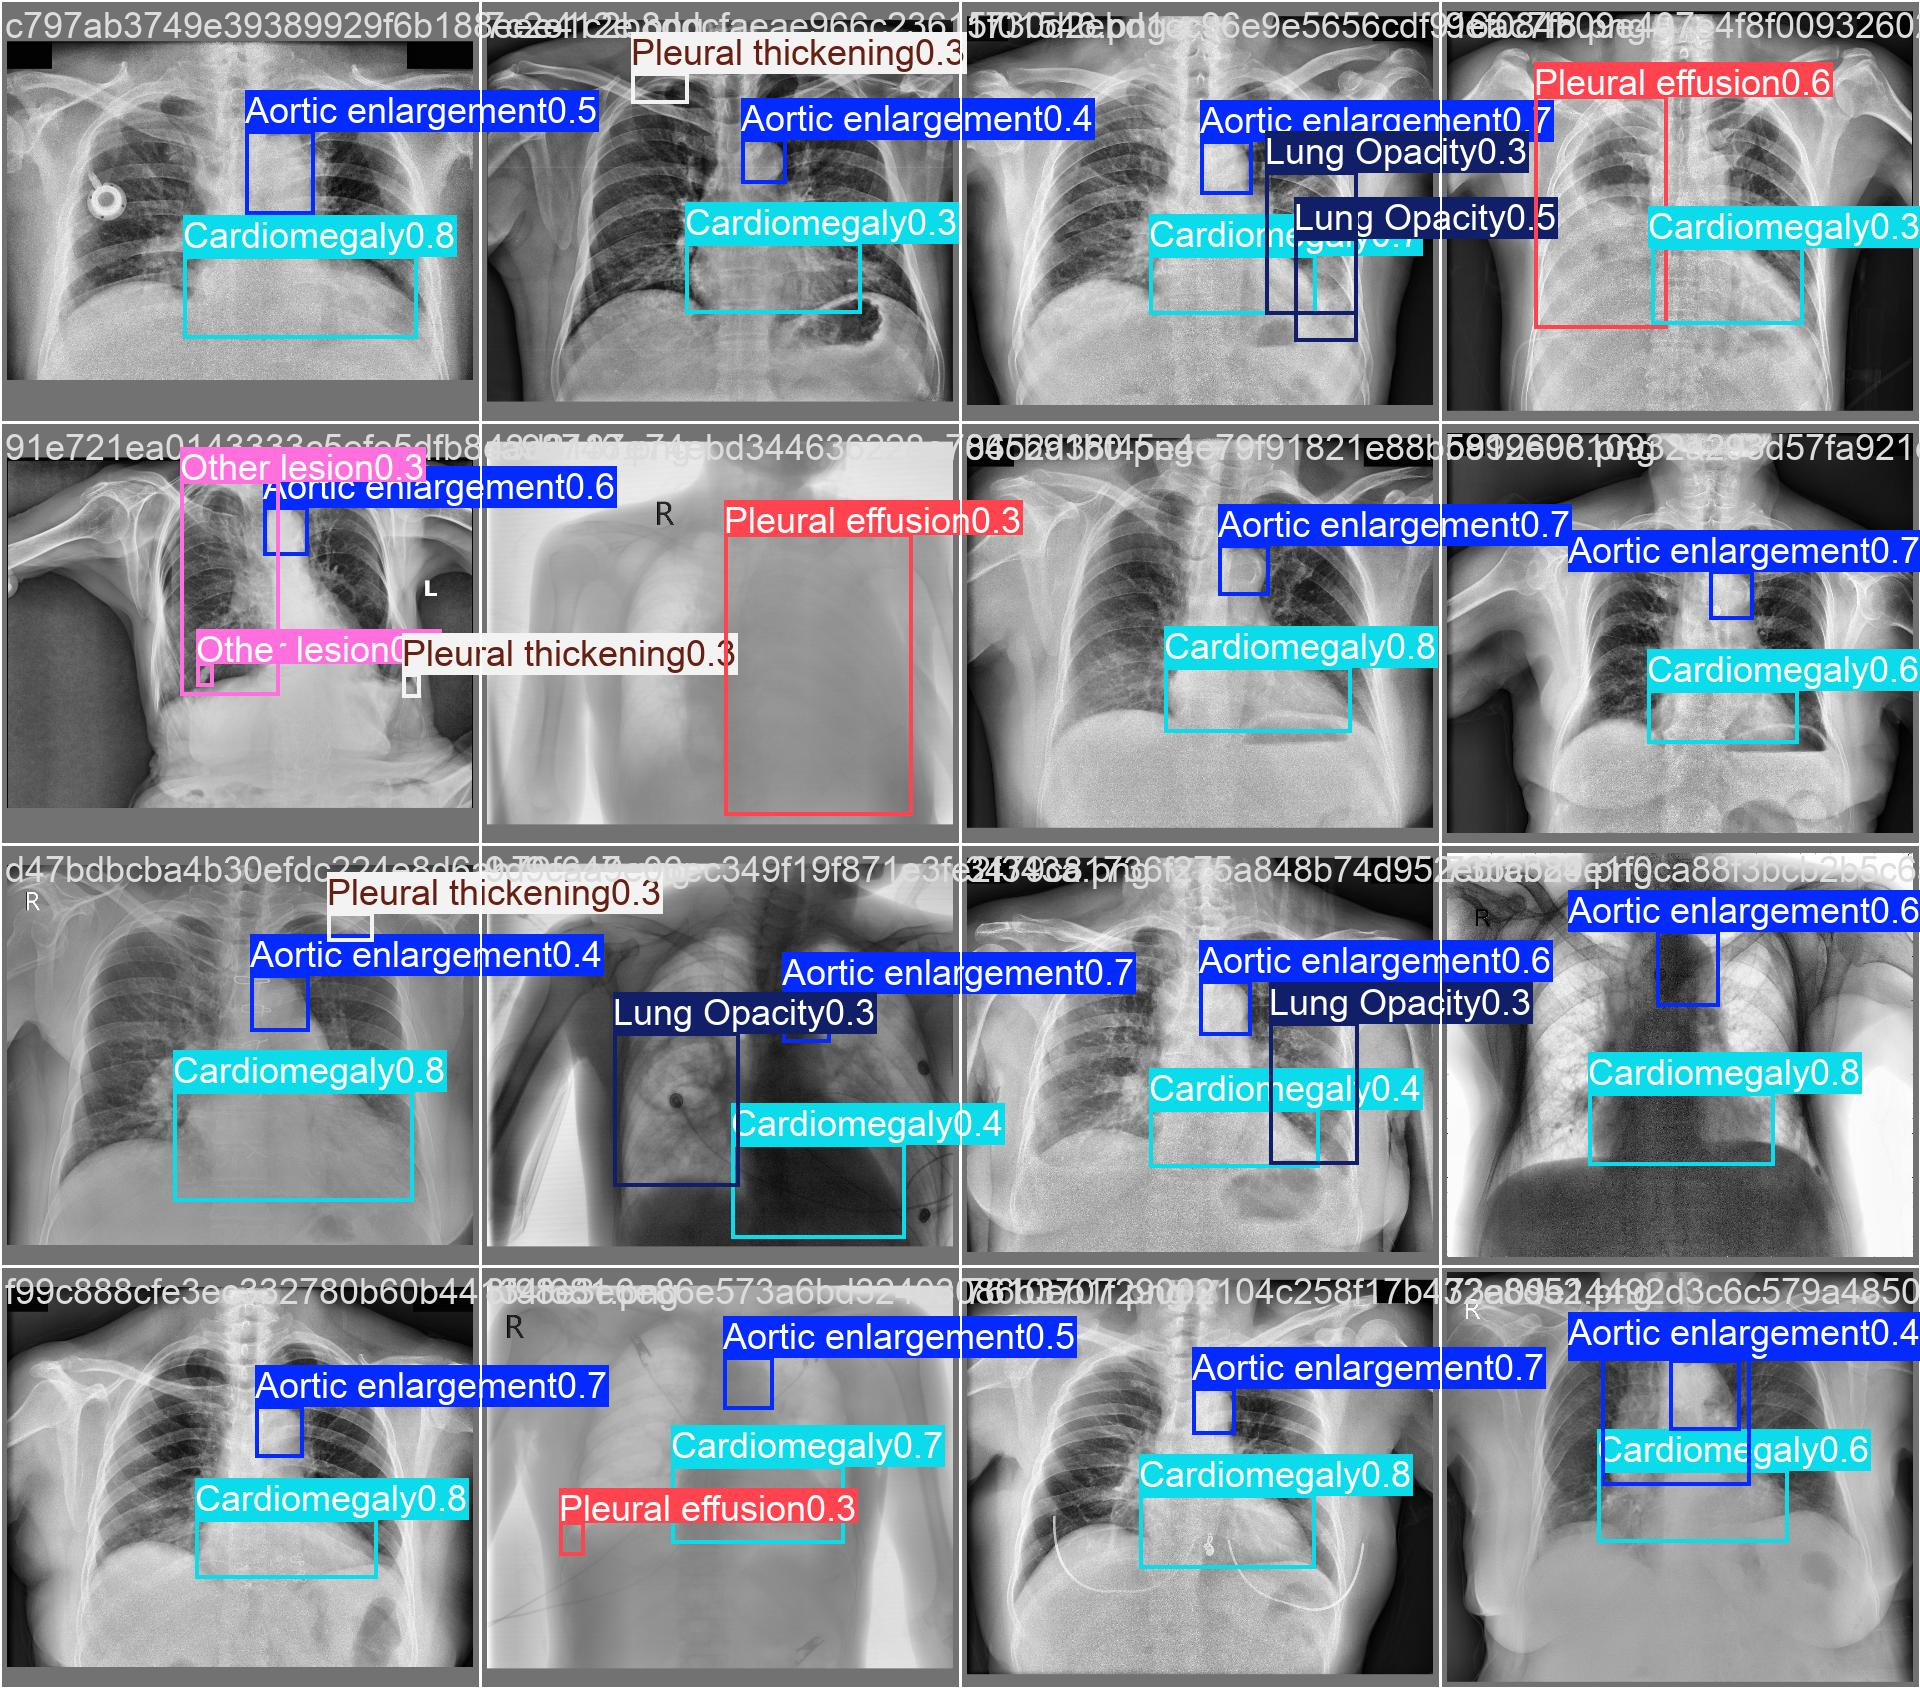

In [17]:
EVAL_DIR = Path("/kaggle/working/evaluation/test_mAP04")

print("=== Confusion Matrix ===")
display(IPImage(EVAL_DIR / "confusion_matrix.png"))

print("\n=== Normalized Confusion Matrix ===")
display(IPImage(EVAL_DIR / "confusion_matrix_normalized.png"))

print("\n=== PR Curve ===")
display(IPImage(EVAL_DIR / "PR_curve.png"))

print("\n=== F1 Curve ===")
display(IPImage(EVAL_DIR / "F1_curve.png"))

print("\n=== Val Batch Predictions ===")
display(IPImage(EVAL_DIR / "val_batch0_pred.jpg"))

In [21]:
import torch
import numpy as np
import cv2
from pathlib import Path
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Model load
model = YOLO(MODEL_PATH)

# Target layer: YOLOv8s ka last C2f layer (features ke liye best)
# YOLOv8 architecture mein last Conv + C2f layer
target_layers = [model.model.model[-2]]  # second-to-last module

print(f"Target layer: {target_layers[0].__class__.__name__}")
print(f"Model loaded")

Target layer: C2f
Model loaded


Model device: cuda:0
Sample: 0046f681f078851293c4e710c4466058.png


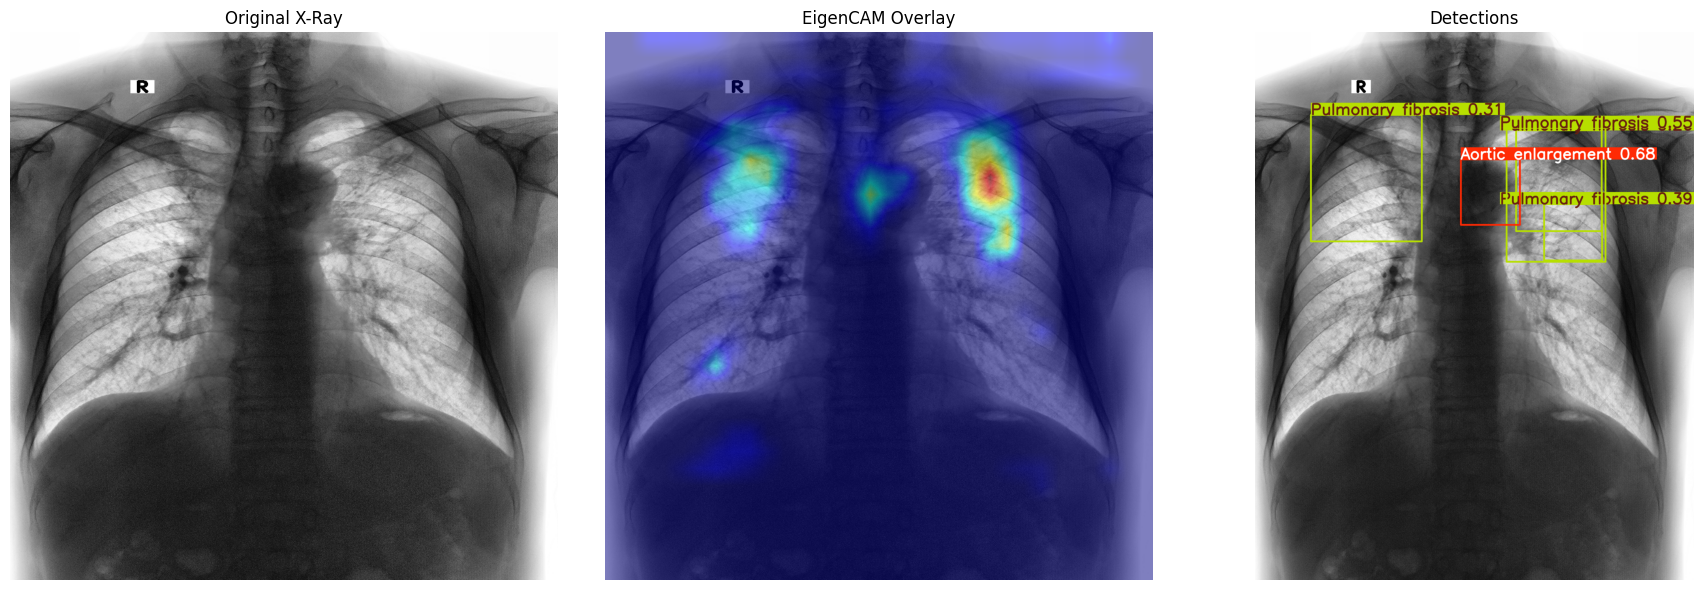

In [23]:
import torch
import numpy as np
import cv2
from pathlib import Path
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.model.to(device).eval()
print(f"Model device: {next(model.model.parameters()).device}")

target_layer = model.model.model[-2]

def preprocess(img_path, size=1024, device='cuda'):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (size, size))
    img_norm = img_resized.astype(np.float32) / 255.0
    tensor = torch.from_numpy(img_norm).permute(2, 0, 1).unsqueeze(0).to(device)
    return tensor, img_norm

def compute_eigencam(model, tensor, target_layer):
    acts = []
    def hook(module, inp, out):
        acts.append(out.detach())
    
    h = target_layer.register_forward_hook(hook)
    with torch.no_grad():
        _ = model.model(tensor)  
    h.remove()
    
    feat = acts[0][0].cpu().numpy()
    C, H, W = feat.shape
    feat_flat = feat.reshape(C, -1)
    
    mean = feat_flat.mean(axis=1, keepdims=True)
    centered = feat_flat - mean
    U, S, Vt = np.linalg.svd(centered, full_matrices=False)
    
    cam = U[:, 0] @ feat_flat
    cam = cam.reshape(H, W)
    cam = np.maximum(cam, 0)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam = cv2.resize(cam, (1024, 1024))
    return cam

# --- Sample ---
sample_img = sorted((Path(DATASET_ROOT) / "images/test").glob("*.png"))[0]
print(f"Sample: {sample_img.name}")

tensor, img_norm = preprocess(sample_img, device=device)
cam = compute_eigencam(model, tensor, target_layer)

# Heatmap overlay
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
overlay = (0.5 * img_norm * 255 + 0.5 * heatmap).astype(np.uint8)

# Detections
results = model.predict(str(sample_img), conf=0.25, verbose=False)
det_img = results[0].plot()

# 3-panel
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_norm); axes[0].set_title("Original X-Ray")
axes[1].imshow(overlay); axes[1].set_title("EigenCAM Overlay")
axes[2].imshow(det_img); axes[2].set_title("Detections")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

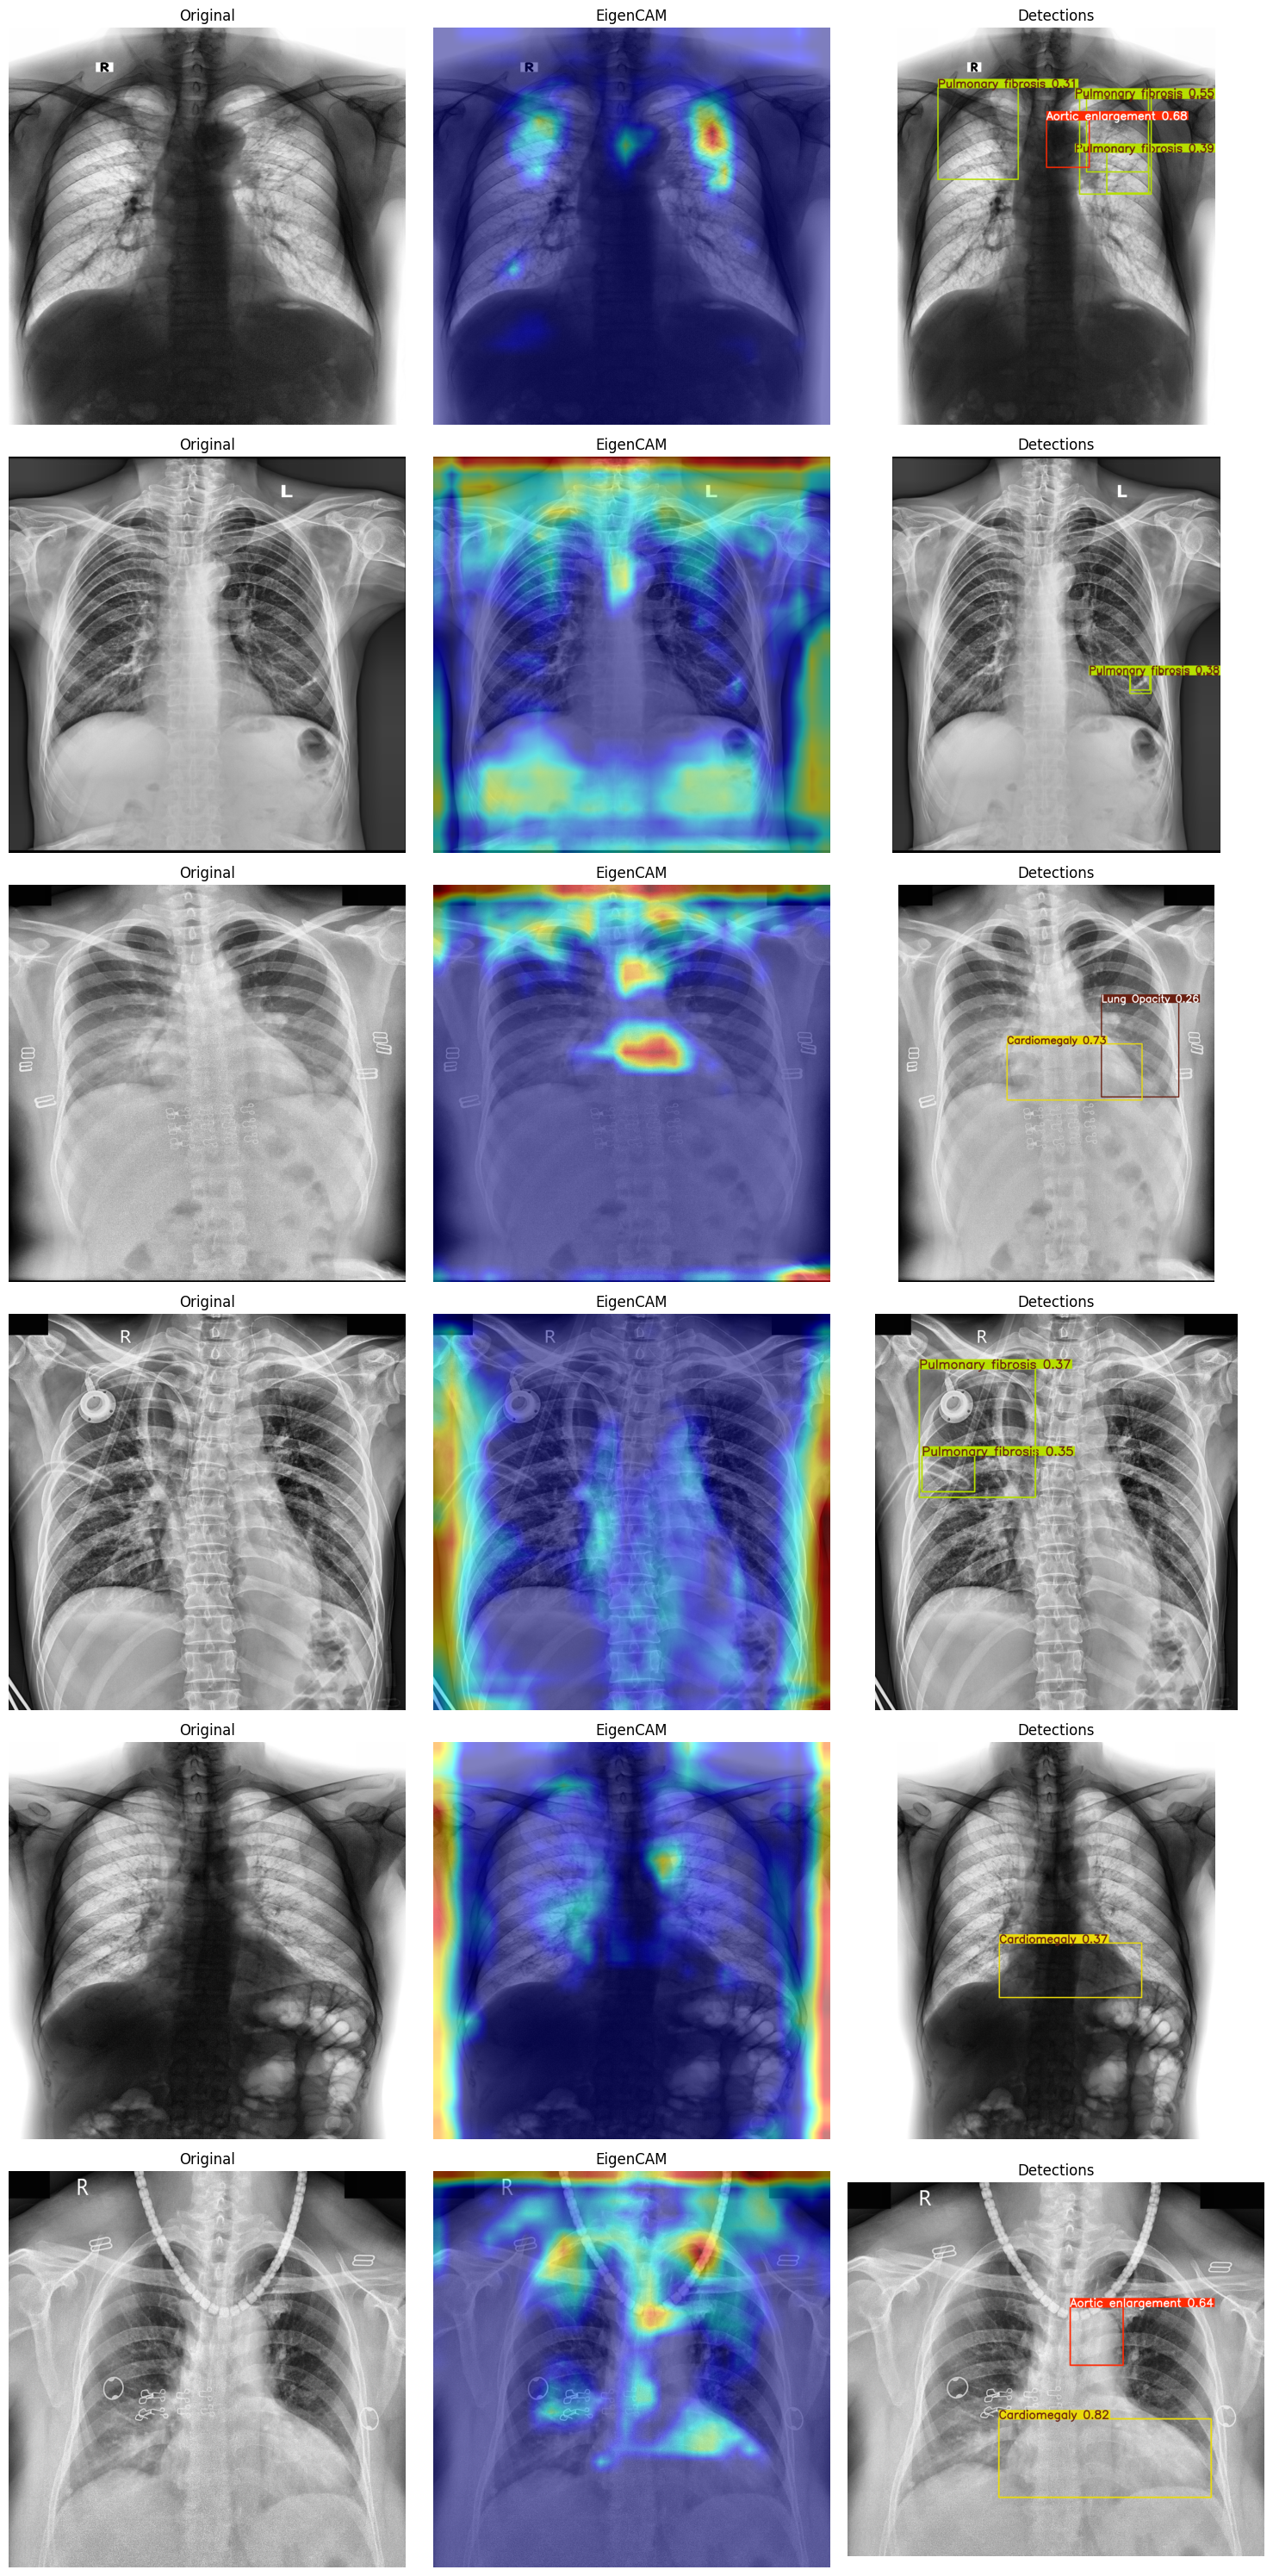

 Saved: /kaggle/working/eigencam_samples.png


In [24]:
# Multiple samples — different classes ke liye
samples = sorted((Path(DATASET_ROOT) / "images/test").glob("*.png"))[:6]

fig, axes = plt.subplots(len(samples), 3, figsize=(15, len(samples)*5))

for i, img_path in enumerate(samples):
    tensor, img_norm = preprocess(img_path, device=device)
    cam = compute_eigencam(model, tensor, target_layer)
    
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (0.5 * img_norm * 255 + 0.5 * heatmap).astype(np.uint8)
    
    results = model.predict(str(img_path), conf=0.25, verbose=False)
    det_img = results[0].plot()
    
    axes[i, 0].imshow(img_norm)
    axes[i, 0].set_title(f"Original")
    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title(f"EigenCAM")
    axes[i, 2].imshow(det_img)
    axes[i, 2].set_title(f"Detections")
    
    for j in range(3):
        axes[i, j].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/eigencam_samples.png', dpi=100, bbox_inches='tight')
plt.show()

print(" Saved: /kaggle/working/eigencam_samples.png")

In [25]:
import os

output_dir = Path("/kaggle/working/eigencam_outputs")
output_dir.mkdir(exist_ok=True)

# 3 sample images
for i, img_path in enumerate(sorted((Path(DATASET_ROOT) / "images/test").glob("*.png"))[:3]):
    tensor, img_norm = preprocess(img_path, device=device)
    cam = compute_eigencam(model, tensor, target_layer)
    
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (0.5 * img_norm * 255 + 0.5 * heatmap).astype(np.uint8)
    
    results = model.predict(str(img_path), conf=0.25, verbose=False)
    det_img = cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB)
    
    # Save individual
    cv2.imwrite(str(output_dir / f"sample_{i}_original.png"), cv2.cvtColor((img_norm*255).astype(np.uint8), cv2.COLOR_RGB2BGR))
    cv2.imwrite(str(output_dir / f"sample_{i}_heatmap.png"), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
    cv2.imwrite(str(output_dir / f"sample_{i}_detections.png"), cv2.cvtColor(det_img, cv2.COLOR_RGB2BGR))

print(f"Saved to {output_dir}")
print(os.listdir(output_dir))

Saved to /kaggle/working/eigencam_outputs
['sample_0_heatmap.png', 'sample_1_detections.png', 'sample_0_detections.png', 'sample_0_original.png', 'sample_1_heatmap.png', 'sample_2_original.png', 'sample_2_detections.png', 'sample_1_original.png', 'sample_2_heatmap.png']


In [27]:
import shutil
from pathlib import Path
from ultralytics import YOLO

#  Model ko writable location par copy
WORKING_MODEL = "/kaggle/working/best.pt"
shutil.copy(MODEL_PATH, WORKING_MODEL)
print(f"Model copied to: {WORKING_MODEL}")

# Writable model load karein
model = YOLO(WORKING_MODEL)

# ONNX export 
print("\nExporting to ONNX...")
onnx_path = model.export(
    format='onnx',
    imgsz=1024,
    opset=12,
    simplify=True,
    dynamic=False,
)

print(f"\n ONNX exported: {onnx_path}")
print(f"   Size: {Path(onnx_path).stat().st_size / (1024**2):.1f} MB")

Model copied to: /kaggle/working/best.pt

Exporting to ONNX...
Ultralytics 8.4.164 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 72 layers, 11,128,680 parameters, 0 gradients, 72.8 GFLOPs

PyTorch: starting from '/kaggle/working/best.pt' with input shape (1, 3, 1024, 1024) BCHW and output shape(s) (1, 12, 21504) (21.5 MB)

ONNX: starting export with onnx 1.22.0 opset 12...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 2.6s, saved as '/kaggle/working/best.onnx' (42.9 MB)

Export complete (3.6s)
Results saved to /kaggle/working/best.onnx
Predict:         yolo predict task=detect model=/kaggle/working/best.onnx imgsz=1024 
Validate:        yolo val task=detect model=/kaggle/working/best.onnx imgsz=1024   
Visualize:       https://netron.app

 ONNX exported: /kaggle/working/best.onnx
   Size: 42.9 MB


In [28]:
import time
import numpy as np
import cv2
import onnxruntime as ort
from pathlib import Path

# ONNX session load
onnx_path = "/kaggle/working/best.onnx"
session = ort.InferenceSession(
    onnx_path,
    providers=['CPUExecutionProvider']   # CPU-only test (HF Spaces ke liye)
)

input_name = session.get_inputs()[0].name
print(f"Input name: {input_name}")
print(f"Input shape: {session.get_inputs()[0].shape}")

# Sample image
sample_img = sorted((Path(DATASET_ROOT) / "images/test").glob("*.png"))[0]
img = cv2.imread(str(sample_img))
img_resized = cv2.resize(img, (1024, 1024))

# Preprocess: BGR → RGB, normalize, CHW, batch
img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
img_norm = img_rgb.astype(np.float32) / 255.0
img_chw = np.transpose(img_norm, (2, 0, 1))
img_input = np.expand_dims(img_chw, axis=0)

# Warmup
print("\nWarming up...")
for _ in range(3):
    _ = session.run(None, {input_name: img_input})

# Benchmark ONNX (CPU)
print("Benchmarking ONNX (CPU)...")
times = []
for _ in range(10):
    t0 = time.perf_counter()
    outputs = session.run(None, {input_name: img_input})
    times.append(time.perf_counter() - t0)

print(f"\n ONNX Inference (CPU):")
print(f"   Mean: {np.mean(times)*1000:.1f} ms")
print(f"   Min:  {np.min(times)*1000:.1f} ms")
print(f"   Max:  {np.max(times)*1000:.1f} ms")

# Output shape
print(f"\nOutput shape: {outputs[0].shape}")
print(f"  (1, 12, 21504) = (batch, 4+8 classes, num_boxes)")

Input name: images
Input shape: [1, 3, 1024, 1024]

Warming up...
Benchmarking ONNX (CPU)...

 ONNX Inference (CPU):
   Mean: 427.6 ms
   Min:  413.5 ms
   Max:  450.5 ms

Output shape: (1, 12, 21504)
  (1, 12, 21504) = (batch, 4+8 classes, num_boxes)


In [30]:
import numpy as np
import cv2

CLASS_NAMES = [
    'Aortic enlargement', 'Cardiomegaly', 'Pleural thickening',
    'Pulmonary fibrosis', 'Lung Opacity', 'Other lesion',
    'Pleural effusion', 'Nodule/Mass'
]

def nms(boxes, scores, iou_threshold=0.45):
    """Non-Maximum Suppression — duplicate boxes remove karta hai."""
    if len(boxes) == 0:
        return []
    
    boxes = np.array(boxes)
    scores = np.array(scores)
    
    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]
    areas = (x2 - x1) * (y2 - y1)
    
    order = scores.argsort()[::-1]
    keep = []
    
    while order.size > 0:
        i = order[0]
        keep.append(i)
        
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        
        w = np.maximum(0.0, xx2 - xx1)
        h = np.maximum(0.0, yy2 - yy1)
        inter = w * h
        iou = inter / (areas[i] + areas[order[1:]] - inter + 1e-6)
        
        inds = np.where(iou <= iou_threshold)[0]
        order = order[inds + 1]
    
    return keep


def parse_onnx_output(output, orig_w, orig_h, input_size=1024,
                       conf_threshold=0.25, iou_threshold=0.45):
    """
    ONNX output → detections list
    
    Output shape: (1, 12, 21504)
    12 = 4 bbox + 8 classes
    """
    # Transpose: (1, 12, 21504) to (21504, 12)
    preds = output[0][0].transpose(1, 0)
    
    # Split bbox and class scores
    boxes_xywh = preds[:, :4]       # (N, 4)
    class_scores = preds[:, 4:]     # (N, 8)
    
    # Best class per box
    class_ids = np.argmax(class_scores, axis=1)
    confidences = np.max(class_scores, axis=1)
    
    # Filter by confidence
    mask = confidences > conf_threshold
    boxes_xywh = boxes_xywh[mask]
    class_ids = class_ids[mask]
    confidences = confidences[mask]
    
    if len(boxes_xywh) == 0:
        return []
    
    # Convert xywh (center) to xyxy (corners)
    cx, cy, w, h = boxes_xywh[:, 0], boxes_xywh[:, 1], boxes_xywh[:, 2], boxes_xywh[:, 3]
    x1 = cx - w / 2
    y1 = cy - h / 2
    x2 = cx + w / 2
    y2 = cy + h / 2
    
    boxes_xyxy = np.stack([x1, y1, x2, y2], axis=1)
    
    # Scale back to original image size
    scale_x = orig_w / input_size
    scale_y = orig_h / input_size
    boxes_xyxy[:, [0, 2]] *= scale_x
    boxes_xyxy[:, [1, 3]] *= scale_y
    
    # Per-class NMS
    detections = []
    for cls_id in np.unique(class_ids):
        cls_mask = class_ids == cls_id
        cls_boxes = boxes_xyxy[cls_mask]
        cls_scores = confidences[cls_mask]
        
        keep = nms(cls_boxes, cls_scores, iou_threshold)
        
        for idx in keep:
            detections.append({
                'class_id': int(cls_id),
                'class_name': CLASS_NAMES[cls_id],
                'confidence': float(cls_scores[idx]),
                'bbox': [float(x) for x in cls_boxes[idx]]
            })
    
    # Sort by confidence
    detections.sort(key=lambda x: -x['confidence'])
    return detections


# Test on sample
sample_img = sorted((Path(DATASET_ROOT) / "images/test").glob("*.png"))[0]
img = cv2.imread(str(sample_img))
h, w = img.shape[:2]

img_resized = cv2.resize(img, (1024, 1024))
img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
img_norm = img_rgb.astype(np.float32) / 255.0
img_input = np.transpose(img_norm, (2, 0, 1))[None, ...]

output = session.run(None, {input_name: img_input})
detections = parse_onnx_output(output, w, h)

print(f"Sample: {sample_img.name}")
print(f"Image size: {w}x{h}")
print(f"Detections: {len(detections)}\n")
for d in detections[:5]:
    print(f"  {d['class_name']:22s} {d['confidence']:.3f}  bbox={[int(x) for x in d['bbox']]}")

Sample: 0046f681f078851293c4e710c4466058.png
Image size: 2304x2880
Detections: 4

  Aortic enlargement     0.710  bbox=[1097, 664, 1388, 1045]
  Pulmonary fibrosis     0.406  bbox=[1356, 514, 1842, 1255]
  Pulmonary fibrosis     0.290  bbox=[1536, 899, 1815, 1207]
  Pulmonary fibrosis     0.255  bbox=[320, 445, 873, 1111]
